# Crosstab & Chi-Square Tool

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/crosstab-chi2/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/crosstab-chi2/demo.ipynb)

> "Compare groups in survey data" — contingency table, chi-square test, effect size, and the exact cells driving the difference.

The **final build of the 120-project portfolio.** The most common survey question - "do these two
categorical variables relate?" - deserves more than eyeballing a crosstab. Chi-square says *whether*
they're associated, Cramer's V says *how strongly*, and standardized residuals say *where*.

**What this notebook covers**
1. The contingency table
2. Chi-square test of independence
3. Cramer's V effect size (significance isn't strength)
4. Standardized residuals: which cells drive it
5. The residual heatmap, visualized


## Step 1 - The contingency table

400 survey responses: subscription plan × satisfaction. The crosstab is the raw comparison - but raw
counts can mislead when group sizes differ.

In [1]:
from crosstab import crosstab_chi2, interpret_v, key_cells, narrate, sample_dataframe

df = sample_dataframe()
result = crosstab_chi2(df, "plan", "satisfaction")
print(result.table)


satisfaction  dissatisfied  neutral  satisfied
plan                                          
enterprise              11       21         33
free                    85       73         35
pro                     36       57         49


## Step 2 - Chi-square: is it real?

Chi-square compares observed counts to what we'd expect if plan and satisfaction were independent. A
small p-value means the pattern is unlikely to be chance.

In [2]:
print(f"chi-square = {result.chi2:.1f}")
print(f"p-value    = {result.p_value:.5f}")
print(f"dof        = {result.dof}")
print(f"significant: {result.significant}")


chi-square = 35.2
p-value    = 0.00000
dof        = 4
significant: True


## Step 3 - Effect size: is it big?

**Significance is not strength.** With enough responses, a trivial association is "significant."
Cramer's V (0-1) tells you whether it actually matters.

In [3]:
print(f"Cramer's V = {result.cramers_v}  ->  {interpret_v(result.cramers_v)}")
print("\n(A tiny p with a small V = real but weak. Report both, always.)")


Cramer's V = 0.21  ->  weak association

(A tiny p with a small V = real but weak. Report both, always.)


## Step 4 - Residuals: *where* is the difference?

The most useful output. Standardized residuals show which cells have far more (or fewer) responses
than independence predicts - the story behind the p-value.

In [4]:
print("Standardized residuals:")
print(result.residuals)
print()
for r, cc, v, d in key_cells(result):
    print(f"  {r} x {cc}: {v:+.1f}σ  ({d} than expected)")
print()
print(narrate(result, "plan", "satisfaction"))


Standardized residuals:
satisfaction  dissatisfied  neutral  satisfied
plan                                          
enterprise           -2.26    -0.71       3.21
free                  2.67     0.02      -2.86
pro                  -1.59     0.46       1.16

  enterprise x satisfied: +3.2σ  (more than expected)
  free x satisfied: -2.9σ  (fewer than expected)
  free x dissatisfied: +2.7σ  (more than expected)
  enterprise x dissatisfied: -2.3σ  (fewer than expected)

plan and satisfaction show a statistically significant association (chi2=35.2, p=0.0000), weak association (Cramer's V=0.21). Biggest driver: enterprise has notably more 'satisfied' than expected (+3.2σ).


## Step 5 - The residual heatmap

Red = more than expected, blue = fewer. The diagonal story pops: enterprise → satisfied (hot red),
free → dissatisfied (red), free → satisfied (blue). That's the association, made visible.

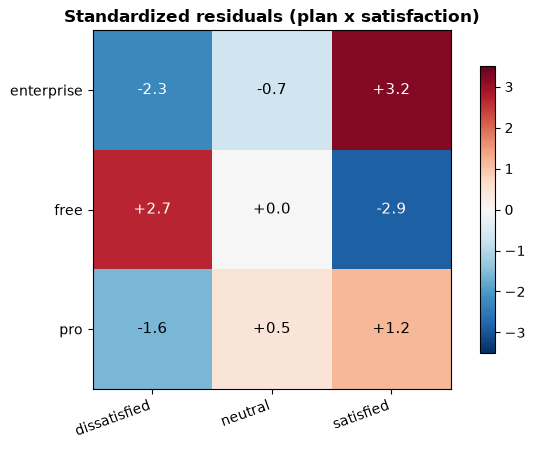

In [5]:
import matplotlib.pyplot as plt

res = result.residuals
fig, ax = plt.subplots(figsize=(6.5, 4.6))
im = ax.imshow(res.values, cmap="RdBu_r", vmin=-3.5, vmax=3.5)
ax.set_xticks(range(len(res.columns)))
ax.set_xticklabels(res.columns, rotation=20, ha="right")
ax.set_yticks(range(len(res.index)))
ax.set_yticklabels(res.index)
for i in range(len(res.index)):
    for j in range(len(res.columns)):
        ax.text(j, i, f"{res.values[i,j]:+.1f}", ha="center", va="center",
                color="white" if abs(res.values[i,j]) > 1.8 else "black", fontsize=11)
ax.set_title("Standardized residuals (plan x satisfaction)", fontsize=12, weight="bold")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig("residuals.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary — and the portfolio comes home

| Question | Answered by |
|----------|-------------|
| Are they associated? | chi-square p-value |
| How strongly? | Cramer's V |
| Where's the difference? | standardized residuals |

Whether, how much, and where - the three things a survey analysis actually needs. Reporting only the
p-value (the usual mistake) hides both the strength and the story.

**This is Day 120 - the last of 120 builds across two portfolios.** From a CSV loader on Day 1 to a
full analytics-engineering, ML, LLMOps, governance, and data-science toolkit. Every build: a core
module, a runnable app, a pre-rendered notebook, and an honest note on the limits.

**Extend it:** add Fisher's exact test for small cells, Bonferroni-correct the residuals, and support
three-way tables.

In [6]:
# --- Try your own survey data ---
# import pandas as pd
# df = pd.read_csv("survey.csv")
# r = crosstab_chi2(df, "segment", "response")
# print(narrate(r, "segment", "response"))


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - **Day 120**,
closing **Month 12: Data Science Cookbook** and the entire 120-build portfolio.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`